<a href="https://colab.research.google.com/github/zydanne-costa/Ondas_ADCP_SCO_Mar_Nov_2025/blob/main/Resultados_PSD_1D_CHU_SEC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Bibliotecas
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.signal import detrend

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# Diretórios dos dados
# ============================================================

dir_chuvoso = "/content/drive/MyDrive/Ondas/Dados/marco2025/SCO1/STrk"

dir_seco = "/content/drive/MyDrive/Ondas/Dados/novembro2025/SCO2/STrk_2"

In [3]:
# ============================================================
# Parâmetros do processamento
# ============================================================

fs = 2.0                 # frequência de amostragem (Hz)

nperseg = 512            # comprimento dos segmentos

noverlap = 256           # 50% de sobreposição

janela = "hann"

In [14]:
def ler_strk(arquivo):
    """
    Lê um arquivo STrk do ADCP.

    Retorna:
        DataFrame contendo os quatro feixes em metros.
    """

    df = pd.read_csv(
        arquivo,
        delim_whitespace=True,
        skiprows=16,
        header=None
    )

    # quatro feixes

    df = df.iloc[:, :4]

    df.columns = ["Beam 1", "Beam 2", "Beam 3", "Beam 4"]

    # remover valores inválidos

    df.replace([-32768, 0], np.nan, inplace=True)

    # mm -> m

    df = df / 1000

    # interpolação

    df = df.interpolate(limit=4)

    return df

In [15]:
from scipy.signal import welch, detrend

def calcular_psd_welch(df, fs=2.0, nperseg=512, noverlap=256):
    """
    Calcula a PSD para os quatro feixes do ADCP utilizando o método de Welch.

    Parâmetros
    ----------
    df : DataFrame
        DataFrame contendo os quatro feixes (Beam1, Beam2, Beam3 e Beam4)
        em metros.

    fs : float
        Frequência de amostragem (Hz).

    nperseg : int
        Número de amostras por segmento.

    noverlap : int
        Número de amostras de sobreposição.

    Retorna
    -------
    resultados : dict
        Dicionário contendo os parâmetros de cada feixe e suas médias.
    """

    resultados = {}

    hm0 = []
    fp = []
    tp = []

    for beam in df.columns:

        serie = df[beam].dropna().values

        # garante tamanho mínimo
        if len(serie) < nperseg:
            continue

        # remove tendência linear
        serie = detrend(serie)

        # Welch
        f, psd = welch(
            serie,
            fs=fs,
            window='hann',
            nperseg=nperseg,
            noverlap=noverlap,
            detrend=False,
            scaling='density'
        )

        # Momento espectral m0
        m0 = np.trapz(psd, f)

        # Altura significativa espectral
        hm0_beam = 4 * np.sqrt(m0)

        # Frequência de pico
        fp_beam = f[np.argmax(psd)]

        # Período de pico
        tp_beam = 1 / fp_beam if fp_beam > 0 else np.nan

        resultados[beam] = {
            "frequencia": f,
            "psd": psd,
            "m0": m0,
            "Hm0": hm0_beam,
            "fp": fp_beam,
            "Tp": tp_beam
        }

        hm0.append(hm0_beam)
        fp.append(fp_beam)
        tp.append(tp_beam)

    resultados["media"] = {
        "Hm0": np.nanmean(hm0),
        "fp": np.nanmean(fp),
        "Tp": np.nanmean(tp)
    }

    return resultados

In [16]:
arquivo = glob.glob(dir_chuvoso + "/*.txt")[0]

df = ler_strk(arquivo)

resultado = calcular_psd_welch(df)

/tmp/ipykernel_678/2664870131.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_678/3987671421.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  m0 = np.trapz(psd, f)


In [17]:
print("Hm0 =", resultado["media"]["Hm0"])
print("fp  =", resultado["media"]["fp"])
print("Tp  =", resultado["media"]["Tp"])

Hm0 = 0.7595011676766189
fp  = 0.12890625
Tp  = 7.757575757575758


In [18]:
print(resultado[df.columns[3]]["Hm0"])

0.9696959422016435


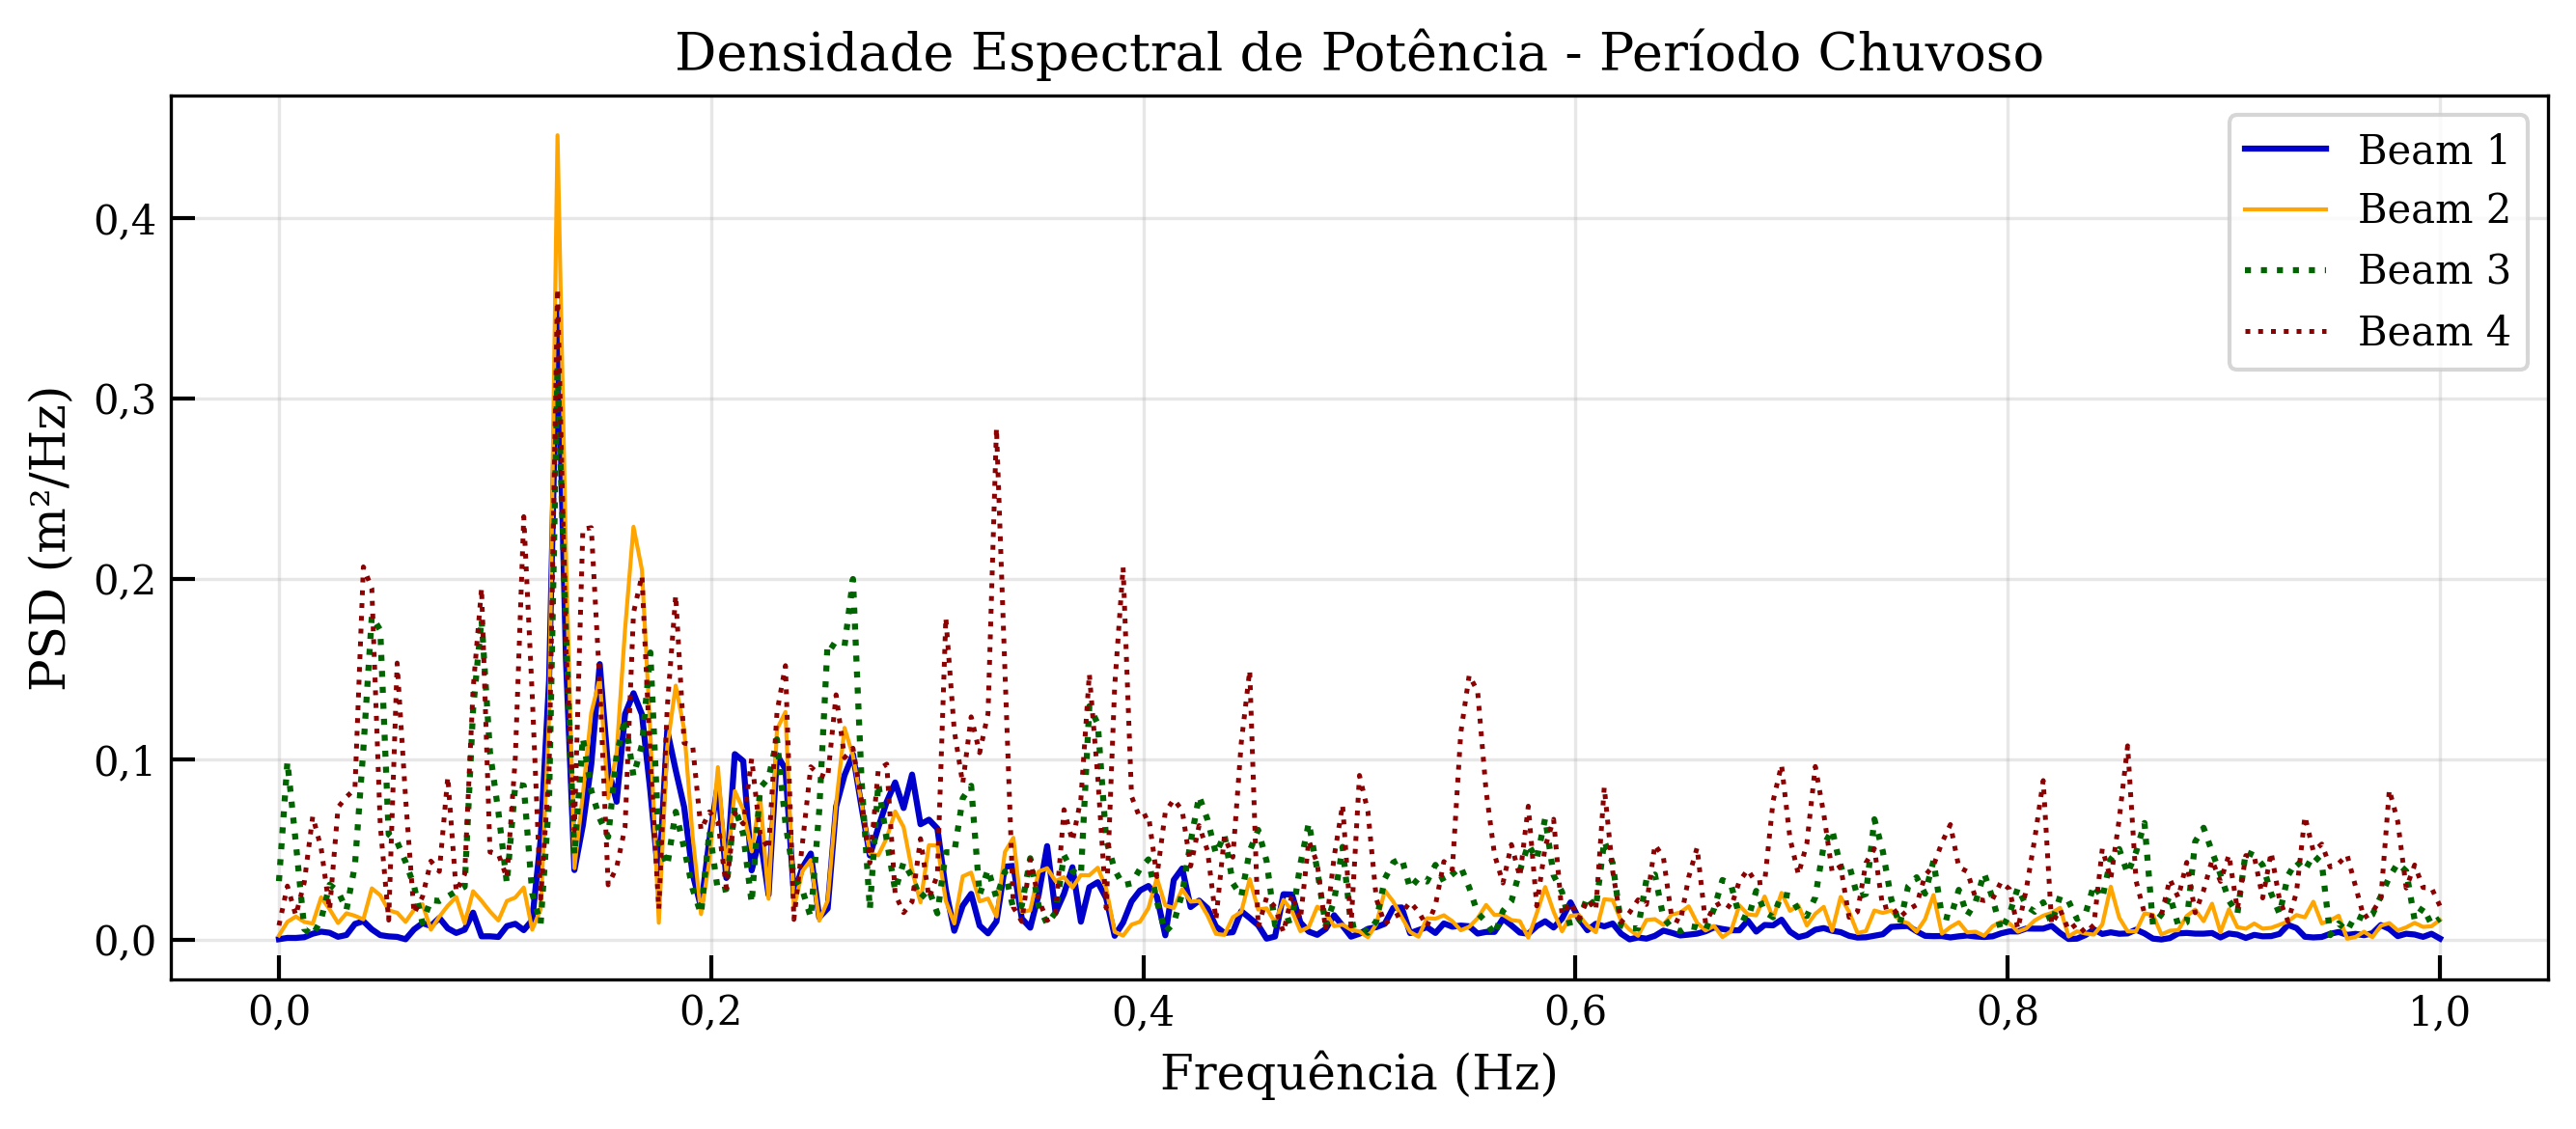

In [48]:
# ============================================================
# PSD de cada Beam
# ============================================================

import matplotlib.ticker as mticker

plt.figure(figsize=(9,4), dpi=300)

plt.rcParams['font.family'] = 'serif'

# Function to format numbers with comma as decimal separator
def comma_formatter(x, pos):
    return f'{x:,.1f}'.replace('.', 'X').replace(',', '.').replace('X', ',')

# Apply the formatter to both x and y axes
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(comma_formatter))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(comma_formatter))

plt.plot(
    resultado["Beam 1"]["frequencia"],
    resultado["Beam 1"]["psd"],
    color="mediumblue",
    linewidth=1.5,
    linestyle="-",
    label="Beam 1"
)

plt.plot(
    resultado["Beam 2"]["frequencia"],
    resultado["Beam 2"]["psd"],
    color="orange",
    linewidth=1.0,
    linestyle="-",
    label="Beam 2"
)

plt.plot(
    resultado["Beam 3"]["frequencia"],
    resultado["Beam 3"]["psd"],
    color="darkgreen",
    linewidth=1.5,
    linestyle=":",
    label="Beam 3"
)

plt.plot(
    resultado["Beam 4"]["frequencia"],
    resultado["Beam 4"]["psd"],
    color="darkred",
    linewidth=1.2,
    linestyle=":",
    label="Beam 4"
)

plt.xlabel("Frequência (Hz)", fontsize=12)
plt.ylabel("PSD (m²/Hz)", fontsize=12)
plt.title("Densidade Espectral de Potência - Período Chuvoso", fontsize=13)

plt.tick_params(direction='in', length=6, width=1)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
# Caminho para salvar a figura
caminho_saida = "/content/drive/MyDrive/Ondas/Dados/Refinados/PSD_chuvoso.png"

# Ajusta o layout
plt.tight_layout()

# Salva a figura
plt.savefig(caminho_saida,
            dpi=300,
            bbox_inches='tight',
            facecolor='white')

# Exibe a figura
plt.show()